# Mushroom Classification: Poisonous or Edible

In [53]:
#importing the dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [54]:
#loading the dataset
df=pd.read_csv("mushrooms.csv")

In [55]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [56]:
#checking for duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

## Checking for null values

In [57]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

- There is no null value in the dataset

## Analysing the unique values in the dataset

In [58]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values | dtype: {df[col].dtype}")


class: 2 unique values | dtype: str
cap-shape: 6 unique values | dtype: str
cap-surface: 4 unique values | dtype: str
cap-color: 10 unique values | dtype: str
bruises: 2 unique values | dtype: str
odor: 9 unique values | dtype: str
gill-attachment: 2 unique values | dtype: str
gill-spacing: 2 unique values | dtype: str
gill-size: 2 unique values | dtype: str
gill-color: 12 unique values | dtype: str
stalk-shape: 2 unique values | dtype: str
stalk-root: 5 unique values | dtype: str
stalk-surface-above-ring: 4 unique values | dtype: str
stalk-surface-below-ring: 4 unique values | dtype: str
stalk-color-above-ring: 9 unique values | dtype: str
stalk-color-below-ring: 9 unique values | dtype: str
veil-type: 1 unique values | dtype: str
veil-color: 4 unique values | dtype: str
ring-number: 3 unique values | dtype: str
ring-type: 5 unique values | dtype: str
spore-print-color: 9 unique values | dtype: str
population: 6 unique values | dtype: str
habitat: 7 unique values | dtype: str


- veil-type has only 1 unique value, hence it can be removed

In [59]:
df=df.drop(columns=['veil-type'])

In [60]:
df['class'].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

## One-Hot Encoding

In [61]:
y=df['class'].map({'p':1,'e':0})

In [62]:
x_raw=df.drop(columns=['class'])

In [63]:
x=pd.get_dummies(x_raw,drop_first=True,dtype=int)

In [64]:
x

,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,1,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,1,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,0,0,0,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
4,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
8120,0,0,0,0,1,0,1,0,0,0,...,0,0,1,0,0,1,0,0,0,0
8121,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
8122,0,0,1,0,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,0


In [65]:
y

0       1
1       0
2       0
3       1
4       0
       ..
8119    0
8120    0
8121    0
8122    1
8123    0
Name: class, Length: 8124, dtype: int64

## Splitting training and testing data

In [66]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## Hyperparameter Tuning using GridSearchCV

In [67]:
rf=RandomForestClassifier(random_state=42)
param_grid_={
    'n_estimators':[50,100,150],
    'max_depth':[3,4,5,6,7,8],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2']
}
cv_strategy=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
grid_search=GridSearchCV(estimator=rf,param_grid=param_grid_,cv=cv_strategy,scoring='f1',n_jobs=-1,verbose=1)
grid_search.fit(x_train,y_train)
print("GridSearchCV Best Results:")
print("Best Parameters: ",grid_search.best_params_)
print("Best CV Score: ",grid_search.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
GridSearchCV Best Results:
Best Parameters:  {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score:  0.9996805111821085


## Training the model

In [68]:
#rf_model= random forest model
rf_model=grid_search.best_estimator_

In [69]:
y_pred=rf_model.predict(x_test)

## Feature importance

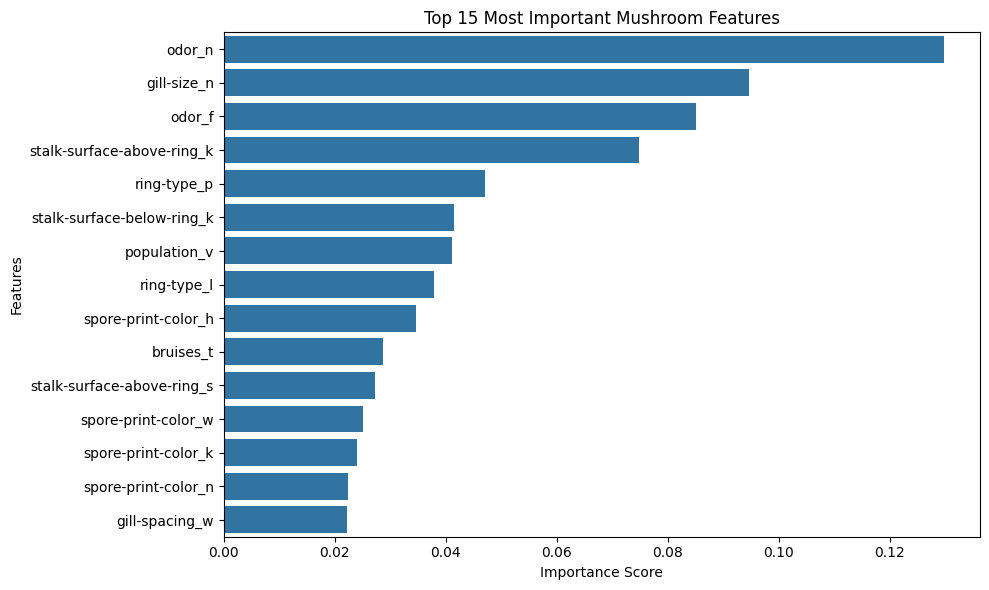

In [70]:
feat_imp=pd.DataFrame({'Feature':x.columns, 'Importance': rf_model.feature_importances_})
top_15_features=feat_imp.sort_values(by='Importance',ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=top_15_features)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Most Important Mushroom Features")
plt.tight_layout()
plt.savefig("Feature importances.png",dpi=300)
plt.show()


### Observations:
- The feature **odor_n** has the most feature importances among all others
- **gill-size_n** and **odor_f** have more feature importance next to **odor_n**

## Model Evaluation

In [71]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print(f"Accuracy score: {accuracy*100:.2f}%")
print(f"Precision score: {precision*100:.2f}%")
print(f"Recall score: {recall*100:.2f}%")
print(f"F1 score: {f1*100:.2f}%")

Accuracy score: 100.00%
Precision score: 100.00%
Recall score: 100.00%
F1 score: 100.00%


## Confusion Matrix

In [72]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[842,   0],
       [  0, 783]])

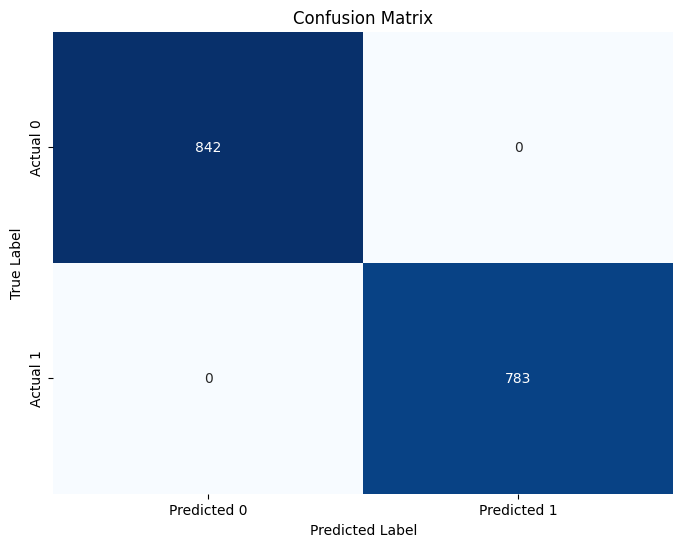

In [73]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("Confusion-matrix.png",dpi=300,bbox_inches='tight')
plt.show()

## Cross validation

In [74]:
cv_scores = cross_val_score(rf_model, x, y, cv=cv_strategy)
print("CV Scores:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())

CV Scores: [1.         1.         1.         0.99876923 1.        ]
Mean: 0.9997538461538461
Std: 0.000492307692307703


## Checking for Overfitting an Generalization

In [75]:
print(f"CV Score:{grid_search.best_score_:.4f}")
print(f"Test Score: {accuracy_score(y_test,y_pred):.4f}")

CV Score:0.9997
Test Score: 1.0000


## Comparison with decision trees

### Hyperparameter Tuning

In [76]:
dt=DecisionTreeClassifier(random_state=42)
param_grid_dt={
    'max_depth':[1,2,3,4,5,6,7,8]
}
grid_search_dt=GridSearchCV(estimator=dt,param_grid=param_grid_dt,cv=cv_strategy,scoring='f1',n_jobs=-1)
grid_search_dt.fit(x_train,y_train)
print("Best Parameters: ",grid_search_dt.best_params_)
print("Best Stable CV Score: ",grid_search_dt.best_score_)


Best Parameters:  {'max_depth': 7}
Best Stable CV Score:  0.9996805111821085


- max_depth=7 is chosen as the best depth by GridSearchCV 

### Training the Model

In [77]:
dt_model=grid_search_dt.best_estimator_

In [78]:
y_pred_dt=dt_model.predict(x_test)

### Decision Tree visualization

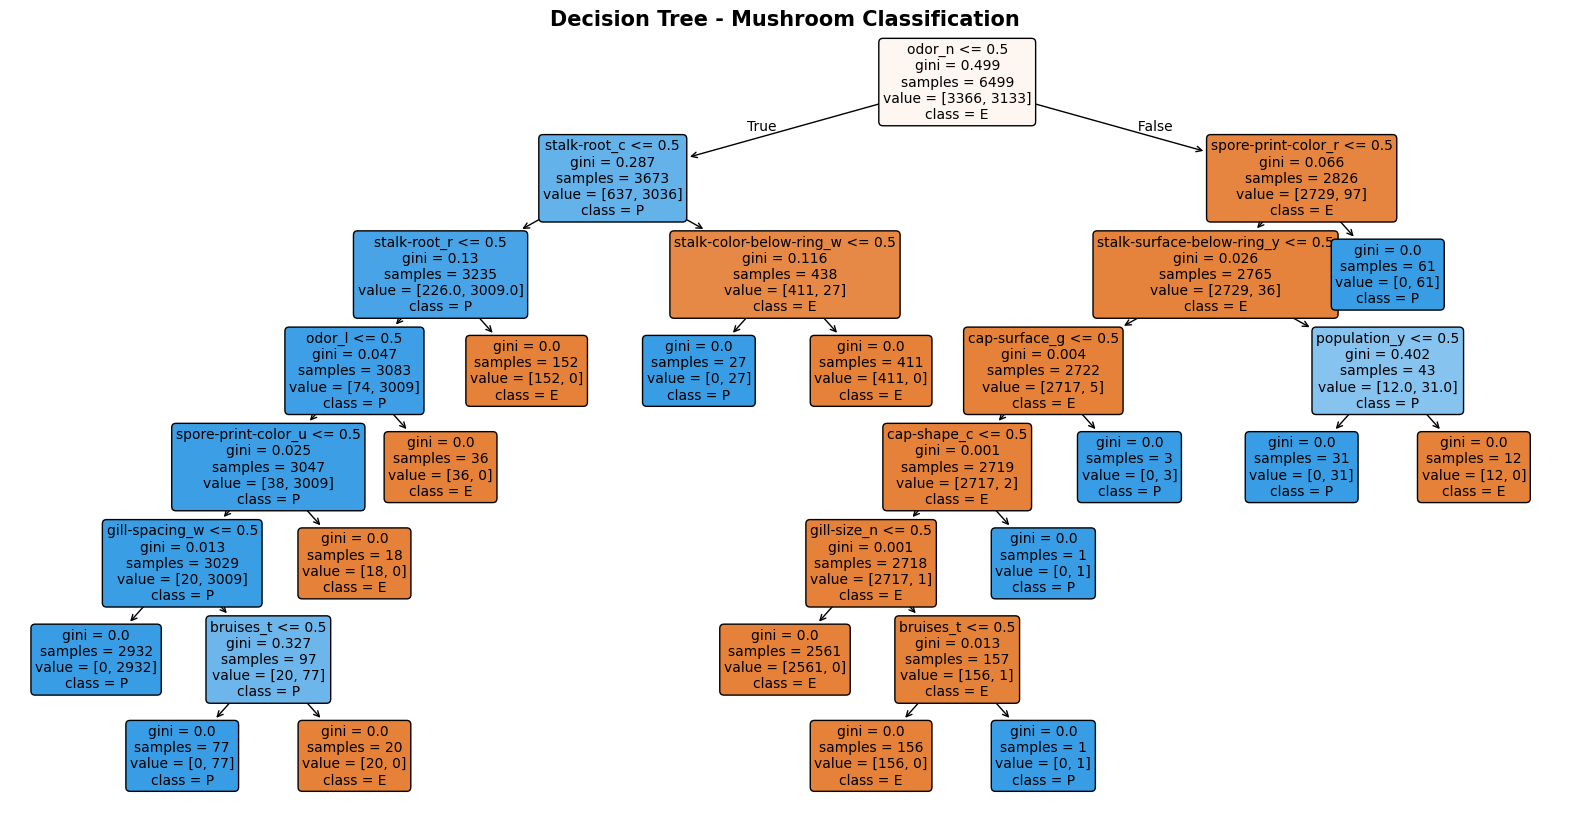

In [79]:
plt.figure(figsize=(20,10))
plot_tree(dt_model,feature_names=list(x.columns),
          class_names=['E','P'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree - Mushroom Classification",fontsize=15,fontweight='bold')
plt.savefig("Tree_visualisation.png",dpi=300,bbox_inches='tight')
plt.show()

### Feature importance

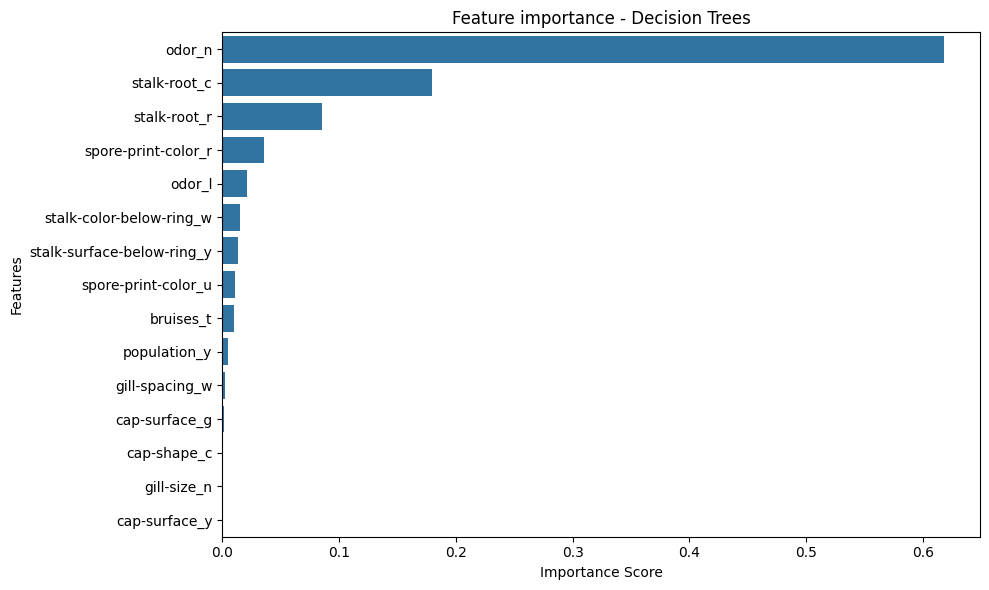

In [80]:
feat_imp_dt=pd.DataFrame({"Feature":x.columns,"Importance":dt_model.feature_importances_})
top_15_features_dt=feat_imp_dt.sort_values(by='Importance',ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=top_15_features_dt)
plt.title("Feature importance - Decision Trees")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("Feature_imp_decision_trees.png",dpi=300)
plt.show()

### Model Evaluation

In [81]:
report=classification_report(y_test,y_pred_dt,output_dict=True)
print(pd.DataFrame(report).transpose())

              precision  recall  f1-score  support
0                   1.0     1.0       1.0    842.0
1                   1.0     1.0       1.0    783.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0   1625.0
weighted avg        1.0     1.0       1.0   1625.0


In [82]:
acc_dt=accuracy_score(y_test,y_pred_dt)
pre_dt=precision_score(y_test,y_pred_dt)
recall_dt=recall_score(y_test,y_pred_dt)
f1_dt=f1_score(y_test,y_pred_dt)
print(f"Accuracy score: {acc_dt*100:.2f}%")
print(f"Precision score: {pre_dt*100:.2f}%")
print(f"Recall score: {recall_dt*100:.2f}%")
print(f"F1 score: {f1_dt*100:.2f}%")

Accuracy score: 100.00%
Precision score: 100.00%
Recall score: 100.00%
F1 score: 100.00%


### Confusion Matrix

In [83]:
cm_dt=confusion_matrix(y_test,y_pred_dt)
cm_dt

array([[842,   0],
       [  0, 783]])

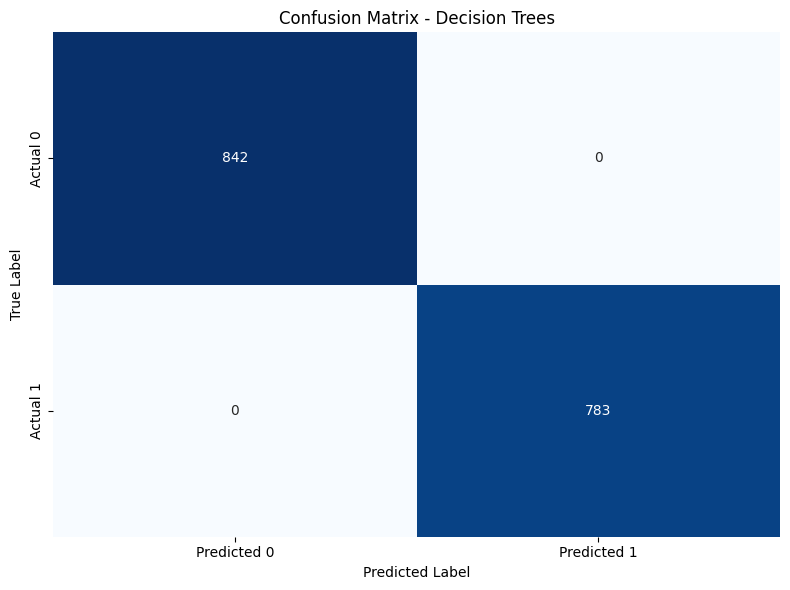

In [84]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt,annot=True, cbar=False, cmap='Blues',fmt='d',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title("Confusion Matrix - Decision Trees")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("Conf_matrix_decisiontrees.png",dpi=300)
plt.show()

### Cross Validation

In [85]:
cv_dt=cross_val_score(dt_model,x,y,cv=cv_strategy)
print("Cross validation scores: ",cv_dt)
print("Cross validation mean score: ",cv_dt.mean())
print("Standard Deviation: ",cv_dt.std())

Cross validation scores:  [1. 1. 1. 1. 1.]
Cross validation mean score:  1.0
Standard Deviation:  0.0


## Comparison between Random forest and Decision trees

In [86]:
metrics={
    'Metrics':['Train accuracy','Test accuracy','Precision','Recall','F1 Score','CV Mean','Standard Deviation'],
    "Random Forest":[accuracy_score(y_train,rf_model.predict(x_train))*100,accuracy*100,precision*100,recall*100,f1*100,cv_scores.mean()*100,cv_scores.std()],
    "Decision Trees": [accuracy_score(y_train,dt_model.predict(x_train))*100,acc_dt*100,pre_dt*100,recall_dt*100,f1_dt*100,cv_dt.mean()*100,cv_dt.std()]
}
comparison=pd.DataFrame(metrics)
print(comparison.to_string(index=False))

           Metrics  Random Forest  Decision Trees
    Train accuracy     100.000000           100.0
     Test accuracy     100.000000           100.0
         Precision     100.000000           100.0
            Recall     100.000000           100.0
          F1 Score     100.000000           100.0
           CV Mean      99.975385           100.0
Standard Deviation       0.000492             0.0
